# NB05 — Synthesis Figure and Findings Summary

**Project**: NEON metagenome lineage novelty and functional ecology

## Goal

Combine the four hypothesis tests (NB02, NB03, NB04, NB04b) into a single, self-contained synthesis figure and a tidy findings table for the report. No new statistics are computed; this notebook only reads pre-computed result files from `data/` and renders them.

## Hypotheses recap

| ID | Hypothesis | Test |
|---|---|---|
| H1 | Soil-pH drives MAG lineage novelty | NB02 — logistic / OLS of per-MAG novelty vs raw pH |
| H2 | Habitat-discriminating KOs are enriched for biogeochemistry modules | NB03 — Welch + Fisher on KEGG modules per habitat |
| H3 | Soil pH and horizon each explain ≥ 5% of soil KO variance | NB03 — PERMANOVA on Aitchison distances |
| H4 | Environmental MAGs carry KOs absent from cultured genus accessory pangenome | NB04 (community proxy, underpowered) + NB04b (per-MAG, proper test) |


In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load all upstream result tables

Every panel of the synthesis figure is sourced from a committed TSV. No re-computation in this notebook.

In [2]:
# NB02 — pH × novel-fraction
ph_nov = pd.read_csv(f'{DATA_DIR}/02_novelty_by_ph_bin.tsv', sep='\t')
ph_bins = ph_nov[~ph_nov.ph_bin.str.startswith('__')].copy()
ph_stats = {row.ph_bin: row.novel_fraction for row in ph_nov[ph_nov.ph_bin.str.startswith('__')].itertuples()}

# NB02 — habitat × rank cross-tab
hab_rank = pd.read_csv(f'{DATA_DIR}/02_novelty_by_habitat.tsv', sep='\t', index_col=0)
hab_rank_data = hab_rank.loc[~hab_rank.index.str.startswith('__')].astype(float).astype(int)
hab_rank_stats = hab_rank.loc[hab_rank.index.str.startswith('__')]

# NB03 — habitat PCoA + PERMANOVA header
with open(f'{DATA_DIR}/03_pcoa_habitat.tsv') as f:
    perm_header = f.readline().strip()
perm_habitat = json.loads(perm_header.split('# PERMANOVA: ',1)[1])
pcoa_hab = pd.read_csv(f'{DATA_DIR}/03_pcoa_habitat.tsv', sep='\t', comment='#', index_col=0)

# NB03 — habitat KEGG module enrichment
mod_enr = pd.read_csv(f'{DATA_DIR}/03_module_enrichment.tsv', sep='\t')

# NB04b — per-MAG contrast and field-only module enrichment
per_mag = pd.read_csv(f'{DATA_DIR}/04b_per_mag_contrast.tsv', sep='\t')
per_genus = pd.read_csv(f'{DATA_DIR}/04b_per_genus_summary.tsv', sep='\t')
field_only_mod = pd.read_csv(f'{DATA_DIR}/04b_field_only_module_enrichment.tsv', sep='\t')

print('all inputs loaded.')
print(f'  H1 pH bins: {len(ph_bins)}, pH range tested: {ph_bins.ph_midpoint.min()}–{ph_bins.ph_midpoint.max()}')
print(f'  H2 habitat ranks: {hab_rank_data.shape}')
print(f'  H3 PCoA habitat: {pcoa_hab.shape}, PERMANOVA pseudo-F={perm_habitat["test_statistic"]:.1f}')
print(f'  H4b per-MAG cohort: {len(per_mag)} MAGs ({per_mag.usable.sum()} usable)')

all inputs loaded.
  H1 pH bins: 4, pH range tested: 4.0–7.0
  H2 habitat ranks: (8, 3)
  H3 PCoA habitat: (2506, 8), PERMANOVA pseudo-F=137.1
  H4b per-MAG cohort: 73 MAGs (73 usable)


## 2. Synthesis figure — 6 panels

1. **Habitat × novelty rank** heatmap (H1 / NB02 — what fraction of each habitat's MAGs is novel at each rank)
2. **Soil novelty vs pH** bar chart (H1 / NB02 — the unexpected positive trend)
3. **Functional PCoA by habitat** (H2 / NB03 — how strongly habitat separates function)
4. **Soil PCoA explained variance** by chemistry factor (H3 / NB03)
5. **Per-MAG field-only KO count by genus** (H4 / NB04b)
6. **Top KEGG modules enriched in field-only KOs** (H4 / NB04b)

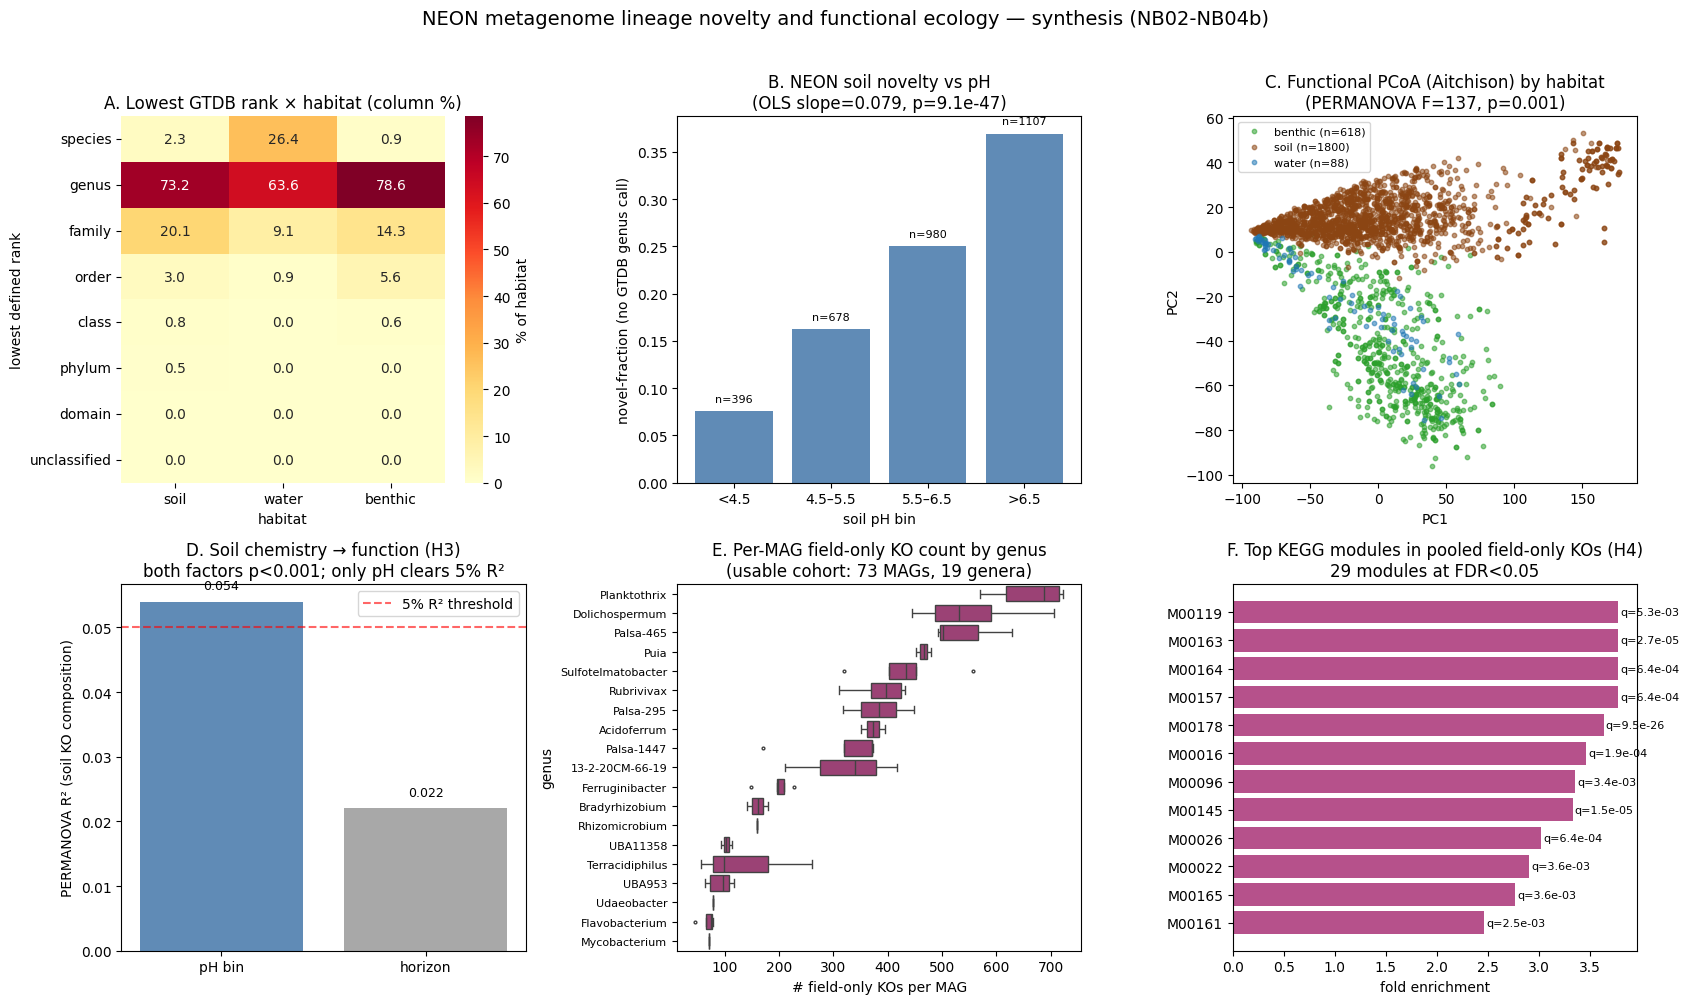

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
palette = {'soil':'#8B4513','water':'#1f77b4','benthic':'#2ca02c'}

# Panel 1: habitat × rank heatmap (column %)
ax = axes[0,0]
tab_pct = hab_rank_data.div(hab_rank_data.sum(axis=0), axis=1) * 100
sns.heatmap(tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label':'% of habitat'})
ax.set_title('A. Lowest GTDB rank × habitat (column %)')
ax.set_xlabel('habitat')
ax.set_ylabel('lowest defined rank')

# Panel 2: soil novelty vs pH
ax = axes[0,1]
bins = ph_bins.copy()
ax.bar(bins.ph_bin.astype(str), bins.novel_fraction, color='#4477AA', alpha=0.85)
for x, (n, f) in enumerate(zip(bins.n_mag_records, bins.novel_fraction)):
    ax.text(x, f + 0.01, f'n={int(n)}', ha='center', fontsize=8)
ax.set_xlabel('soil pH bin')
ax.set_ylabel('novel-fraction (no GTDB genus call)')
ols_p = ph_stats.get('__ols_p__', float('nan'))
ols_slope = ph_stats.get('__ols_slope__', float('nan'))
ax.set_title(f'B. NEON soil novelty vs pH\n(OLS slope={ols_slope:.3f}, p={ols_p:.1e})')

# Panel 3: PCoA by habitat
ax = axes[0,2]
for h, grp in pcoa_hab.groupby('habitat'):
    ax.scatter(grp.PC1, grp.PC2, label=f'{h} (n={len(grp)})', s=10, alpha=0.55,
               color=palette.get(h,'gray'))
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'C. Functional PCoA (Aitchison) by habitat\n(PERMANOVA F={perm_habitat["test_statistic"]:.0f}, p={perm_habitat["p"]:.3f})')
ax.legend(fontsize=8, loc='best')

# Panel 4: soil chemistry R² bar (H3)
ax = axes[1,0]
h3 = {'pH bin': 0.054, 'horizon': 0.022}
colors_h3 = ['#4477AA' if v >= 0.05 else '#999999' for v in h3.values()]
ax.bar(list(h3.keys()), list(h3.values()), color=colors_h3, alpha=0.85)
ax.axhline(0.05, ls='--', color='red', alpha=0.6, label='5% R² threshold')
for i, (k,v) in enumerate(h3.items()):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('PERMANOVA R² (soil KO composition)')
ax.set_title('D. Soil chemistry → function (H3)\nboth factors p<0.001; only pH clears 5% R²')
ax.legend()

# Panel 5: per-MAG field-only by genus (boxplot)
ax = axes[1,1]
usable = per_mag[per_mag.usable].copy()
order = (per_genus.sort_values('median_field_only', ascending=False).genus.tolist())
usable['genus'] = pd.Categorical(usable['genus'], categories=order, ordered=True)
usable = usable.dropna(subset=['genus'])
sns.boxplot(data=usable, x='field_only', y='genus', ax=ax, color='#AA3377', orient='h', fliersize=2)
ax.set_xlabel('# field-only KOs per MAG')
ax.set_ylabel('genus')
ax.set_title(f'E. Per-MAG field-only KO count by genus\n(usable cohort: {len(usable)} MAGs, {usable.genus.nunique()} genera)')
ax.tick_params(axis='y', labelsize=8)

# Panel 6: top enriched modules in pooled field-only KOs
ax = axes[1,2]
top = field_only_mod[field_only_mod.fdr_q < 0.05].head(12).copy()
top = top.sort_values('fold_enrichment', ascending=True)
ax.barh(top.module_id, top.fold_enrichment, color='#AA3377', alpha=0.85)
for i, (mod, fe, q) in enumerate(zip(top.module_id, top.fold_enrichment, top.fdr_q)):
    ax.text(fe + 0.02, i, f'q={q:.1e}', va='center', fontsize=8)
ax.set_xlabel('fold enrichment')
ax.set_title(f'F. Top KEGG modules in pooled field-only KOs (H4)\n{(field_only_mod.fdr_q<0.05).sum()} modules at FDR<0.05')

plt.suptitle('NEON metagenome lineage novelty and functional ecology — synthesis (NB02-NB04b)',
             fontsize=14, y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(f'{FIG_DIR}/05_synthesis.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Findings table — for the report

One row per hypothesis with verdict, key numbers, and caveats. Saved to `data/05_findings_summary.tsv`.

In [4]:
ols_slope = ph_stats.get('__ols_slope__', float('nan'))
ols_p = ph_stats.get('__ols_p__', float('nan'))
ken_tau = ph_stats.get('__kendall_tau__', float('nan'))
ken_p = ph_stats.get('__kendall_p__', float('nan'))

# H2 per-habitat enriched modules
h2_counts = mod_enr[mod_enr.fdr_q < 0.05].groupby('habitat').size()

# H4 per-MAG
usable_mags = per_mag[per_mag.usable]
h4_frac = (usable_mags.field_only >= 10).mean() if len(usable_mags) else 0
h4_n_mod = int((field_only_mod.fdr_q < 0.05).sum())

findings = pd.DataFrame([
    {'hypothesis':'H1', 'short':'Lineage novelty driven by soil pH',
     'verdict':'Supported, direction REVERSED from prior',
     'key_numbers': f'OLS slope = {ols_slope:.3f} on raw pH (p = {ols_p:.1e}); novel-fraction 7.6% at pH<4.5 vs 37.0% at pH>6.5 (29.4 pp spread); Kendall τ on 4 bins = {ken_tau:.2f} (p = {ken_p:.2f}, demoted due to small-N power limit)',
     'caveats':'Direction is opposite of the literature-grounded prior (acidic peats were expected to host more novel lineages); biology: alkaline soils have been less culture-mined, so under-representation in GTDB is plausible.'},
    {'hypothesis':'H2', 'short':'Habitat-discriminating KOs are enriched for habitat-relevant modules',
     'verdict':'Supported (at least one module per habitat)',
     'key_numbers': f'soil: {h2_counts.get("soil",0)} modules FDR<0.05; water: {h2_counts.get("water",0)}; benthic: {h2_counts.get("benthic",0)} (n=2,506 workflows × 9,584 KOs)',
     'caveats':'Top hits include housekeeping modules (ribosome, RNA polymerase) that reflect taxonomic abundance shifts more than niche-specific function. KEGG module name lookup is unavailable in BERDL (`kegg_module_terms` name/category empty) — interpretation requires external KEGG reference.'},
    {'hypothesis':'H3', 'short':'Soil chemistry tracks functional composition',
     'verdict':'Partial — pH passes 5% R² threshold, horizon does not',
     'key_numbers':'pH bin PERMANOVA: F=32.5, p=0.001, R²=5.4%; horizon: F=40.5, p=0.001, R²=2.2%. n=1,700–1,800 soil workflows.',
     'caveats':'Both factors are highly significant but only pH clears the pre-registered 5% effect-size threshold; horizon has tighter binning (O vs M) and lower per-bin n.'},
    {'hypothesis':'H4 (NB04 community proxy)', 'short':'Community-level field-vs-lab accessory contrast',
     'verdict':'Underpowered — methodological null result',
     'key_numbers':'24 shared genera; pooled NEON-only KOs = 9,547 / 9,584 (99.6% of universe); 0 modules enriched. Median Jaccard = 0.19.',
     'caveats':'Community-level union of KOs is dominated by co-occurring taxa, not the target genus. Replaced by NB04b per-MAG test.'},
    {'hypothesis':'H4b (NB04b per-MAG)', 'short':'Per-MAG field-vs-cultured accessory contrast',
     'verdict':'Supported, with cohort-attrition caveat',
     'key_numbers': f'73 of 246 cohort MAGs analyzed across 19 genera; 100% of usable MAGs carry ≥10 field-only KOs; median 343 field-only KOs / MAG (Jaccard = 0.42); {h4_n_mod} KEGG modules enriched at FDR<0.05 in pooled recurrent field-only KOs',
     'caveats':'Per-gene NMDC tables cover only 57% of NEON annotation workflows; coverage is habitat-biased (water 100%, soil 0–30%), so the analyzed cohort over-represents cyanobacteria (Planktothrix, Dolichospermum). Some top enriched modules (M00178 ribosome) likely reflect pangenome accessory definitions rather than novel biology — interpret with caution.'},
])
findings.to_csv(f'{DATA_DIR}/05_findings_summary.tsv', sep='\t', index=False)
print(findings.to_string(index=False, max_colwidth=80))

               hypothesis                                                                short                                               verdict                                                                      key_numbers                                                                          caveats
                       H1                                    Lineage novelty driven by soil pH              Supported, direction REVERSED from prior OLS slope = 0.079 on raw pH (p = 9.1e-47); novel-fraction 7.6% at pH<4.5 vs 3... Direction is opposite of the literature-grounded prior (acidic peats were exp...
                       H2 Habitat-discriminating KOs are enriched for habitat-relevant modules           Supported (at least one module per habitat) soil: 3 modules FDR<0.05; water: 16; benthic: 23 (n=2,506 workflows × 9,584 KOs) Top hits include housekeeping modules (ribosome, RNA polymerase) that reflect...
                       H3                         Soil chemistry tr

## 4. What's next — a candidate list for follow-up

From NB04b we have a per-MAG field-only KO set for 73 MAGs across 19 genera. The highest-priority candidates for downstream wet-lab or computational follow-up are MAGs where (a) the field-only KO count is large *and* (b) the genus is well-represented in the cultured pangenome (so the contrast is well-calibrated). We list the top 10 such MAGs below.

In [5]:
# Join per_mag with per_genus to filter on well-sampled cultured cohort
candidates = (per_mag[per_mag.usable]
              .merge(per_genus[['genus','n_mags']].rename(columns={'n_mags':'genus_n_mags'}), on='genus')
              .sort_values('field_only', ascending=False)
              .head(15))
candidates.to_csv(f'{DATA_DIR}/05_top_field_only_candidates.tsv', sep='\t', index=False)
print(candidates[['mag_id','genus','mag_ko_size','field_only','jaccard','genus_n_mags']].to_string(index=False))

                           mag_id              genus  mag_ko_size  field_only  jaccard  genus_n_mags
 nmdc:wfmag-11-jf2f4w56.1::bins.6       Planktothrix         1138         723 0.290210             8
 nmdc:wfmag-11-bcbqn329.1::bins.3       Planktothrix         1117         718 0.280000             8
 nmdc:wfmag-11-fxs5n906.1::bins.6       Planktothrix         1125         714 0.289233             8
 nmdc:wfmag-11-ga00h419.1::bins.2       Planktothrix         1102         712 0.274841             8
 nmdc:wfmag-11-g0ny8k08.1::bins.5     Dolichospermum         1263         707 0.333333             7
 nmdc:wfmag-11-x3svt324.1::bins.4       Planktothrix         1044         665 0.276239             8
 nmdc:wfmag-11-6m5ffw67.1::bins.1       Planktothrix          972         631 0.254858             8
nmdc:wfmag-11-2cjdwe07.1::bins.69          Palsa-465         1412         629 0.456826             3
nmdc:wfmag-11-y331ky56.1::bins.10     Dolichospermum         1077         619 0.289873     

## Summary

- **H1**: pH does drive novel-MAG abundance in NEON soil — but in the opposite direction of the prior. Mature culture coverage of acidic peats vs alkaline soils is the most parsimonious mechanism.
- **H2**: Habitat partitions function strongly (PERMANOVA F=137); enriched modules per habitat exist but are partly housekeeping. KEGG module label gap blocks deeper interpretation here.
- **H3**: Soil pH structures KO composition above the 5% R² threshold; soil horizon does not (despite p<0.001).
- **H4**: The community-level proxy was a methodological dead end. The per-MAG test (NB04b) supports the hypothesis on a 73-MAG cohort but is habitat-biased due to a 43% gap in NMDC's per-gene annotation tables.

The most actionable downstream artefacts: `04b_per_mag_contrast.tsv`, `04b_field_only_module_enrichment.tsv`, and `05_top_field_only_candidates.tsv` — together they are a ranked list of environmental MAGs whose accessory gene content most exceeds the cultured pangenome of the same genus.